# Entrevista No.3

### Ejercicio 1: Limpieza y análisis exploratorio básico

* Tienes un archivo CSV llamado `ventas_tienda.csv` con las siguientes columnas: `fecha,producto,categoria,precio,cantidad,ciudad`.

***OBEJTIVOS*** --> `combinar estructuras de Python puro con análisis y visualización de datos.`
1. Carga el archivo manualmente (sin pandas al inicio).
   - Usa manejo de archivos (with open) y listas/diccionarios.
   - Convierte cada fila en un diccionario y guárdalos en una lista.
   - Maneja excepciones por formato o valores vacíos.
2. Calcula:
   - Total de ventas por producto.
   - Total de ventas por categoría.
   - Producto más vendido (por cantidad).
   - Ingreso total (precio * cantidad).
3. Luego:
   - Carga el mismo archivo con pandas y verifica si los resultados coinciden.
   - Grafica con matplotlib las ventas por categoría (barras).

In [10]:
def toFloat(value):
    try:
        return float(value)
    except ValueError:
        print("Valor no válido. Intenta de nuevo.")
    return 0

def toInt(value):
    try:
        return int(value)
    except ValueError:
        print("Valor no válido. Intenta de nuevo.")
    return 0.0

def parseRawData(columns, data):
    ### Lista de diccionario
    solds = []
    for datum in data:
        #Limpiamos y separamos por ,
        log = datum.strip().split(",")
        sold = {}
        for i, j in enumerate(log):
            if i == 3 or i== 4:
                sold[columns[i]] = toFloat(j)
            else:
                sold[columns[i]] = j
        solds.append(sold)
    return solds 

def printList(lt):
    for i,l in enumerate(lt):
        print(f"{i}. {l}")
        

def totalByProdcut(solds):
    ### diccionario con todos los tipos de prodcutos
    solds_prodcuts = {}
    for sold in solds:
        if sold["producto"] not in solds_prodcuts.keys():
            solds_prodcuts[sold["producto"]] = sold["cantidad"] * sold["precio"]
        else:
            solds_prodcuts[sold["producto"]] += sold["cantidad"] * sold["precio"]
        
    return solds_prodcuts 

def totalByTag(solds):
    ### diccionario con todos los tipos de prodcutos
    solds_tag = {}
    for sold in solds:
        if sold["categoria"] not in solds_tag.keys():
            solds_tag[sold["categoria"]] = sold["cantidad"] * sold["precio"]
        else:
            solds_tag[sold["categoria"]] += sold["cantidad"] * sold["precio"]
        
    return solds_tag 

def topProductSold(solds):
    ### diccionario con todos los tipos de prodcutos
    solds_cant = {}
    for sold in solds:
        if sold["producto"] not in solds_cant.keys():
            solds_cant[sold["producto"]] = sold["cantidad"]
        else:
            solds_cant[sold["producto"]] += sold["cantidad"]
    
    max_cant = 0
    max_name = ""
    for product in solds_cant.keys():
        if solds_cant[product] > max_cant:
            max_cant = solds_cant[product]
            max_name = product
    print(f"\nEl producto: {max_name} fue el más vendido con {max_cant} unidades")

def finalBalanceSold(solds):
    ### diccionario con todos los tipos de prodcutos
    total = 0.0
    for sold in solds:
        total += sold["precio"] * sold["cantidad"]
            
    print(f"\nTotal Vendido: ${total}")

# 1. Carga el archivo manualmente (sin pandas al inicio).
try:
    with open("BACKLOG/ventas_tienda.csv", "r", encoding='utf-8') as file:
        columns=file.readline().strip().split(",")
        solds = parseRawData(columns, file.readlines())
except Exception as e:
    print(f"Ocurrió un error al exportar: {type(e).__name__} - {e}")

### 2. Calculos
### printList(solds)
### Total de ventas por producto.
total = totalByProdcut(solds)
print("\nTotales Producto:\n", total)
### Total de ventas por categoría.
total = totalByTag(solds)
print("\nTotales Categoria:\n", total)
### Producto más vendido (por cantidad).
topProductSold(solds)
### Ingreso total (precio * cantidad).
finalBalanceSold(solds)


Totales Producto:
 {'Audífonos': 3130.0, 'Camiseta': 2865.0, 'Laptop': 37600.0, 'Zapatos': 3820.0, 'Refrigerador': 8900.0, 'Televisión': 44600.0, 'Taza': 1610.0, 'Mochila': 4610.0, 'Licuadora': 4870.0}

Totales Categoria:
 {'Categoría Electrónica': 85330.0, 'Categoría Ropa': 6685.0, 'Categoría Hogar': 15380.0, 'Categoría Accesorios': 4610.0}

El producto: Camiseta fue el más vendido con 16.0 unidades

Total Vendido: $112005.0



Venta por Producto:
        producto  ingreso
0     Audífonos     3130
1      Camiseta     2865
2        Laptop    37600
3     Licuadora     4870
4       Mochila     4610
5  Refrigerador     8900
6          Taza     1610
7    Televisión    44600
8       Zapatos     3820

Venta por Categoría:
                categoria  ingreso
0   Categoría Accesorios     4610
1  Categoría Electrónica    85330
2        Categoría Hogar    15380
3         Categoría Ropa     6685

Producto más vendido: Camiseta (16 unidades)

Total Vendido: $112005


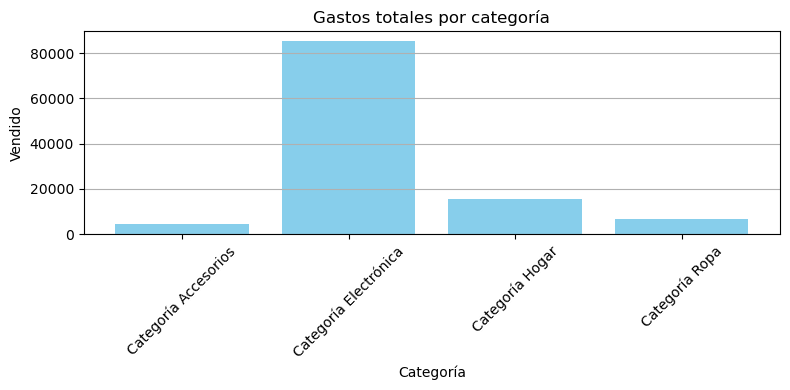

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

### Ahora pandas y matplot por categoría
df = pd.read_csv("BACKLOG/ventas_tienda.csv")
df["ingreso"] = df["precio"] * df["cantidad"]

### Agrupoar por producto
print("\nVenta por Producto:\n",  df.groupby("producto")["ingreso"].sum().reset_index())

### Agrupar por categoría
categorias = df.groupby("categoria")["ingreso"].sum().reset_index()
print("\nVenta por Categoría:\n", categorias)

### Sacar el maximo de un producto
ventas_por_producto = df.groupby("producto")["cantidad"].sum()

producto_max = ventas_por_producto.idxmax()
cantidad_max = ventas_por_producto.max()

print(f"\nProducto más vendido: {producto_max} ({cantidad_max} unidades)")

### Total vendido
print(f"\nTotal Vendido: ${df["ingreso"].sum()}")

### Graficiación por categoría (barras)

plt.figure(figsize=(8, 4))
plt.bar(categorias["categoria"], categorias["ingreso"], color="skyblue")
plt.title("Gastos totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Vendido")
plt.xticks(rotation=45)  # Rota las etiquetas si son muchas o largas
plt.grid(axis="y")
plt.tight_layout()
plt.show()

***PROPUESTA SOLUCIÓN***

=== Python puro (manual) ===
Totales por producto: {'Audífonos': 3130.0, 'Camiseta': 2865.0, 'Laptop': 37600.0, 'Zapatos': 3820.0, 'Refrigerador': 8900.0, 'Televisión': 44600.0, 'Taza': 1610.0, 'Mochila': 4610.0, 'Licuadora': 4870.0}
Totales por categoria: {'Categoría Electrónica': 85330.0, 'Categoría Ropa': 6685.0, 'Categoría Hogar': 15380.0, 'Categoría Accesorios': 4610.0}
Top producto por cantidad: [('Camiseta', 16), ('Taza', 13), ('Audífonos', 9)]
Total Vendido (manual): $112,005.00

=== Verificación con pandas ===

Venta por Producto (pandas):
       producto  ingreso
0     Audífonos     3130
1      Camiseta     2865
2        Laptop    37600
3     Licuadora     4870
4       Mochila     4610
5  Refrigerador     8900
6          Taza     1610
7    Televisión    44600
8       Zapatos     3820

Venta por Categoría (pandas):
               categoria  ingreso
0   Categoría Accesorios     4610
1  Categoría Electrónica    85330
2        Categoría Hogar    15380
3         Categoría Ropa    

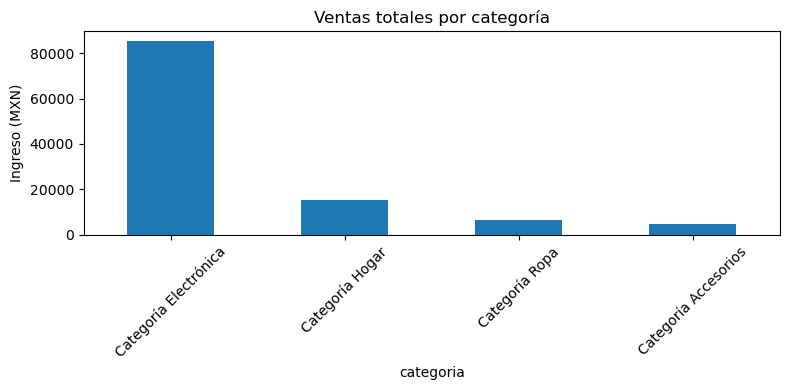

In [42]:
# ventas_analysis.py
import csv
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

def safe_float(s, default=0.0, row_no=None, field=None):
    try:
        return float(s)
    except (ValueError, TypeError):
        if row_no:
            print(f"Fila {row_no}: valor inválido en '{field}' -> reemplazo por {default}")
        return default

def parse_csv(path):
    solds = []
    with open(path, encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader, start=2):  # start=2: header=linea 1
            # normalizar espacios
            row = {k: (v.strip() if isinstance(v, str) else v) for k, v in row.items()}
            # validaciones básicas
            precio = safe_float(row.get('precio', 0), row_no=i, field='precio')
            try:
                cantidad = int(float(row.get('cantidad', 0)))
            except (ValueError, TypeError):
                print(f"Fila {i}: cantidad inválida -> 0")
                cantidad = 0
            solds.append({
                'fecha': row.get('fecha'),
                'producto': row.get('producto'),
                'categoria': row.get('categoria'),
                'precio': precio,
                'cantidad': cantidad,
                'ciudad': row.get('ciudad'),
            })
    return solds

def total_by_product(solds):
    agg = defaultdict(float)
    for s in solds:
        agg[s['producto']] += s['precio'] * s['cantidad']
    return dict(agg)

def total_by_category(solds):
    agg = defaultdict(float)
    for s in solds:
        agg[s['categoria']] += s['precio'] * s['cantidad']
    return dict(agg)

def top_product_by_quantity(solds, top_n=1):
    agg = defaultdict(int)
    for s in solds:
        agg[s['producto']] += s['cantidad']
    sorted_products = sorted(agg.items(), key=lambda x: x[1], reverse=True)
    return sorted_products[:top_n]

def total_revenue(solds):
    return sum(s['precio'] * s['cantidad'] for s in solds)

if __name__ == '__main__':
    path = "BACKLOG/ventas_tienda.csv"
    solds = parse_csv(path)

    print("=== Python puro (manual) ===")
    print("Totales por producto:", total_by_product(solds))
    print("Totales por categoria:", total_by_category(solds))
    print("Top producto por cantidad:", top_product_by_quantity(solds, top_n=3))
    print(f"Total Vendido (manual): ${total_revenue(solds):,.2f}")

    # --- Verificación con pandas ---
    print("\n=== Verificación con pandas ===")
    df = pd.read_csv(path, encoding='utf-8')
    df['precio'] = pd.to_numeric(df['precio'], errors='coerce').fillna(0)
    df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce').fillna(0).astype(int)
    df['ingreso'] = df['precio'] * df['cantidad']

    print("\nVenta por Producto (pandas):")
    print(df.groupby('producto')['ingreso'].sum().reset_index())

    print("\nVenta por Categoría (pandas):")
    categorias = df.groupby('categoria')['ingreso'].sum().reset_index()
    print(categorias)

    print(f"\nProducto más vendido (pandas): {df.groupby('producto')['cantidad'].sum().idxmax()} "
          f"({df.groupby('producto')['cantidad'].sum().max()} unidades)")

    print(f"\nTotal Vendido (pandas): ${df['ingreso'].sum():,.2f}")

    # --- Gráfica ---
    ax = df.groupby('categoria')['ingreso'].sum().sort_values(ascending=False).plot.bar(figsize=(8,4))
    ax.set_title("Ventas totales por categoría")
    ax.set_ylabel("Ingreso (MXN)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Ejercicio 2: Preprocesamiento y modelado

* Temas involucrados: pandas, NumPy, imputación, escalamiento, codificación One-Hot, regresión lineal, métricas de regresión.
* Descarga el dataset de ejemplo: `https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv`.

***OBJETIVOS***: practicar un flujo real de preparación y evaluación de modelo supervisado.
1. Carga el dataset y elige las columnas:
   - Predictoras: carat, depth, table, x, y, z, cut, color, clarity.
   - Variable objetivo: price.
2. Realiza:
   - Imputación de valores faltantes (si los hay).
   - Codificación One-Hot para variables categóricas.
   - Escalamiento MinMaxScaler para las numéricas.
   - Divide en entrenamiento (80%) y prueba (20%).
3. Entrena una Regresión Lineal con scikit-learn.
4. Evalúa con métricas: MAE, MSE, R².

In [4]:
import pandas as pd
import numpy as np

#1. Cargamos nuestra información
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv')
print("="*5, "1. Data Información", "="*5, "\n")
print(df.head())

===== 1. Data Información ===== 

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [5]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder ### Escalamiento y One Hot

#2.1 Codificación.

### Declaramos nuestro codificador y transformamos nuestras variables
codificador = OneHotEncoder(sparse_output=False)
codificacion = codificador.fit_transform(df[["cut", "color", "clarity"]])

### La variable códificador solo tiene los 1, 0 en listas de listas.
### Debemos asginarles a la columna que representan con una expresión.
nombres_columnas = [
    f"{feature}_{categoria}"
    for feature, categorias in zip(["cut", "color", "clarity"], codificador.categories_)
    for categoria in categorias
]

### Crear nuevo DataFrame codificado apartir de la listas de lista.
df_codificado = pd.DataFrame(codificacion, columns=nombres_columnas)

### Concatenar al original y borrar las otras columnas de manera permanente.
df = pd.concat([df.reset_index(drop=True), df_codificado.reset_index(drop=True)], axis=1)
df.drop("cut", axis="columns", inplace=True)
df.drop("color", axis="columns", inplace=True)
df.drop("clarity", axis="columns", inplace=True)

print("="*5, "2. Codificación", "="*5, "\n")
print(df.head())

===== 2. Codificación ===== 

   carat  depth  table  price     x     y     z  cut_Fair  cut_Good  \
0   0.23   61.5   55.0    326  3.95  3.98  2.43       0.0       0.0   
1   0.21   59.8   61.0    326  3.89  3.84  2.31       0.0       0.0   
2   0.23   56.9   65.0    327  4.05  4.07  2.31       0.0       1.0   
3   0.29   62.4   58.0    334  4.20  4.23  2.63       0.0       0.0   
4   0.31   63.3   58.0    335  4.34  4.35  2.75       0.0       1.0   

   cut_Ideal  ...  color_I  color_J  clarity_I1  clarity_IF  clarity_SI1  \
0        1.0  ...      0.0      0.0         0.0         0.0          0.0   
1        0.0  ...      0.0      0.0         0.0         0.0          1.0   
2        0.0  ...      0.0      0.0         0.0         0.0          0.0   
3        0.0  ...      1.0      0.0         0.0         0.0          0.0   
4        0.0  ...      0.0      1.0         0.0         0.0          0.0   

   clarity_SI2  clarity_VS1  clarity_VS2  clarity_VVS1  clarity_VVS2  
0          1.0 

In [6]:
#2.2 Escalamiento
columnas_a_escalar = ["carat", "depth", "table" , "x", "y", "z"]

### Declaramos nuestro escalador de datos
escalador = MinMaxScaler()
df[columnas_a_escalar] = escalador.fit_transform(df[columnas_a_escalar])

print("=" * 5, "3. Datos Escalados", "=" * 5, "\n")
print(df.head())

===== 3. Datos Escalados ===== 

      carat     depth     table  price         x         y         z  \
0  0.006237  0.513889  0.230769    326  0.367784  0.067572  0.076415   
1  0.002079  0.466667  0.346154    326  0.362197  0.065195  0.072642   
2  0.006237  0.386111  0.423077    327  0.377095  0.069100  0.072642   
3  0.018711  0.538889  0.288462    334  0.391061  0.071817  0.082704   
4  0.022869  0.563889  0.288462    335  0.404097  0.073854  0.086478   

   cut_Fair  cut_Good  cut_Ideal  ...  color_I  color_J  clarity_I1  \
0       0.0       0.0        1.0  ...      0.0      0.0         0.0   
1       0.0       0.0        0.0  ...      0.0      0.0         0.0   
2       0.0       1.0        0.0  ...      0.0      0.0         0.0   
3       0.0       0.0        0.0  ...      1.0      0.0         0.0   
4       0.0       1.0        0.0  ...      0.0      1.0         0.0   

   clarity_IF  clarity_SI1  clarity_SI2  clarity_VS1  clarity_VS2  \
0         0.0          0.0          1.

In [7]:
### 2.3 Divide en entrenamiento (80%) y prueba (20%).

from sklearn.model_selection import train_test_split ### Imputación

### Declaramos nuestras caracteristicas y variable objetivo
X = df.drop(columns=["price"])
y = df["price"]
print("Distribución de clases en y:")
print(y.value_counts(normalize=True))

### Claramos el 80% y 20% de datos separados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state=42
)

Distribución de clases en y:
price
605      0.002447
802      0.002354
625      0.002336
828      0.002317
776      0.002299
           ...   
8816     0.000019
14704    0.000019
14699    0.000019
14698    0.000019
9793     0.000019
Name: proportion, Length: 11602, dtype: float64


In [8]:
### 3.Entrena una Regresión Lineal con scikit-learn.

### Modelos y Métricas
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelo = LinearRegression().fit(X_train, y_train)

# 1. Hacer predicciones
y_pred = modelo.predict(X_test)

# 2. Evaluamos nuestro modelo.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 3. Imprimir resultados
print("="*5, "6. Evaluación del Modelo", "="*5)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

===== 6. Evaluación del Modelo =====
MAE: 737.1528
MSE: 1288712.4626
R2: 0.9189


***SOLUCIÓN***

1. Creo que es buena idea sacar las columnas `features` y `target` desde el principio.
2. En este dataset no hay datos faltantes, pero podemos revisarlo `X.isnull().sum()` y `X.isnan().sum()`.
3. Aunque rellenar nosotros con la media podría causar un sesgo o un sobreajuste.
4. Esta librería es nueva para mi `from sklearn.compose import ColumnTransformer`

***NOTAS***
* `sklearn.compose.ColumnTransformer`: Sirve para aplicar transformaciones diferentes a distintas columnas de un DataFrame o array, lo cual es muy útil en preprocesamiento de datos, especialmente cuando tienes una combinación de columnas numéricas y categóricas.
* Escalar columnas numéricas (por ejemplo, con `StandardScaler`), Codificar columnas categóricas (por ejemplo, con `OneHotEncoder`)

```python
# Crear el transformador
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(), columnas_categoricas)
    ]
)
```

* Un `pipeline` en `sklearn.pipeline.Pipeline` es una herramienta que te permite `encadenar múltiples pasos de procesamiento de datos y modelado en un único objeto`.
* Es muy útil para mantener el código limpio, organizado y evitar fugas de datos (`data leakage`) durante el entrenamiento y evaluación del modelo.
* ***¿Para qué sirve un pipeline?***
  - `Encapsular` todo el flujo de trabajo de machine learning (`preprocesamiento` + `modelo`).
  - Evitar errores comunes, como entrenar el modelo con datos que ya han sido transformados con información del conjunto de prueba.
  - Facilitar el uso de herramientas como `GridSearchCV` para ajustar hiperparámetros.
  - Hacer que tu código sea reutilizable y reproducible.

```python
# Pipeline completo
pipeline = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', RandomForestClassifier())
])
# Entrenar pipeline
pipeline.fit(X_train, y_train)
# Predecir
y_pred = pipeline.predict(X_test)
```


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Cargar el dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)

# 2. Seleccionar columnas de interés
features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut', 'color', 'clarity']
target = 'price'
X = df[features]
y = df[target]

# 3. Verificar valores faltantes
print("Valores faltantes:\n", X.isnull().sum())

# Si hay valores faltantes, se imputarían aquí. En este dataset normalmente no hay,
# pero podemos dejarlo listo:
X = X.fillna(X.mean(numeric_only=True))  # imputación simple para numéricas

# 4. Columnas categóricas y numéricas
cat_cols = ['cut', 'color', 'clarity']
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

# 5. Preprocesamiento: One-Hot + Escalado
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 6. Crear pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 7. Separar datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Entrenar el modelo
pipeline.fit(X_train, y_train)

# 9. Predicciones
y_pred = pipeline.predict(X_test)

# 10. Evaluación
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.4f}")

Valores faltantes:
 carat      0
depth      0
table      0
x          0
y          0
z          0
cut        0
color      0
clarity    0
dtype: int64
MAE: 737.15
MSE: 1288705.48
R²: 0.9189


### Ejercicio 3: Clasificación y manejo de clases desbalanceadas

`Temas involucrados`: regresión logística, métricas de clasificación, curvas ROC, pesos, validación cruzada, seaborn.

Enunciado:

Usa el dataset de cáncer de mama de sklearn: ```python from sklearn.datasets import load_breast_cancer```

***OBJETIVOS***: comprender cómo ajustar modelos ante clases desbalanceadas y evaluar correctamente su rendimiento.
1. Carga los datos en un DataFrame.
2. Entrena un modelo de Regresión Logística para clasificar benigno vs maligno.
3. Evalúa con:
   - `accuracy`, `precision`, `recall`, `f1`, `roc_auc`.
4. Repite el entrenamiento `asignando pesos inversos` a las clases (class_weight='balanced').
5. Visualiza con seaborn:
   - `Matriz de confusión`.
   - `Curva ROC`.

In [25]:
# 1. Carga los datos en un DataFrame.
from sklearn.datasets import load_breast_cancer
import pandas as pd

### Data nos traera un diccionario con todos los datos, así que podemos aprovechar para tener la información separada.
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

== Normal ==
Accuracy Score : 0.98
Precision Score: 0.97
Recall Score   : 1.00
F1 Score       : 0.99
ROC AUC        : 0.98


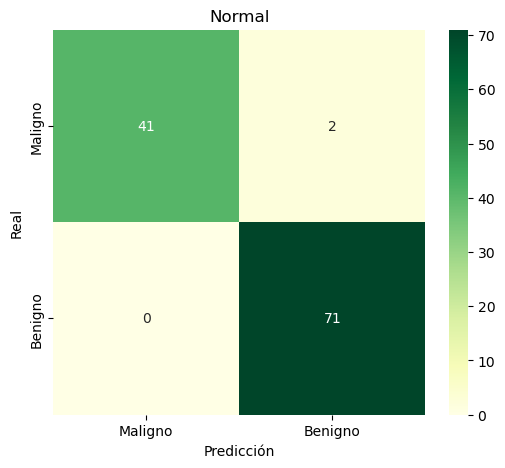

== Pesos ==
Accuracy Score : 0.75
Precision Score: 1.00
Recall Score   : 0.61
F1 Score       : 0.75
ROC AUC        : 0.80


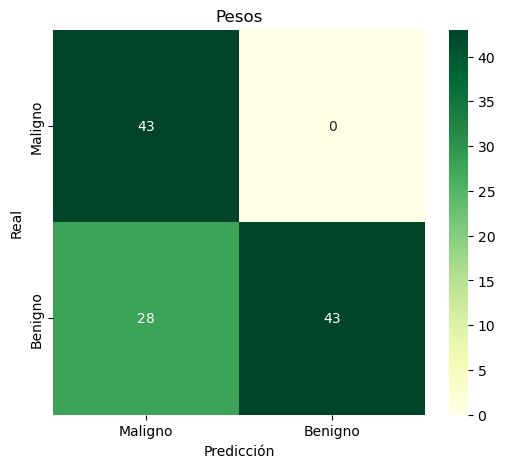

In [30]:
# 2. Entrena un modelo de Regresión Logística para clasificar benigno vs maligno
### Debemos escalar y separar la información 
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix


def printConfuseMatrix(y_test, y_pred, title="Matriz de Confusión"):
    """ Visualiza la matriz de confusión con métricas """
    
    # Calculamos la matriz
    matrix = confusion_matrix(y_test, y_pred)
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    # Imprimir métricas
    print(f"== {title} ==")
    print(f"Accuracy Score : {accuracy:.2f}")
    print(f"Precision Score: {precision:.2f}")
    print(f"Recall Score   : {recall:.2f}")
    print(f"F1 Score       : {f1:.2f}")
    print(f"ROC AUC        : {roc:.2f}")

    # Visualización
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix,
                annot=True,
                fmt='d',
                cmap='YlGn',
                xticklabels=["Maligno", "Benigno"],
                yticklabels=["Maligno", "Benigno"])
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()

### Escalamiento
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), X.columns)
])

### Pipeline con nuestro proceso
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('fit', LogisticRegression())
])

### Hacemos nuestra información para entrenar y evaluar nuestro modelo.
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42)

### Entrenar el modelo
pipeline.fit(X_train, y_train)
 
### Para pode sacar las metricas pasamos los datos reales y los datos que prediga.
printConfuseMatrix(y_test, pipeline.predict(X_test), "Normal") 

# Pipeline con LogisticRegression con pesos
pipeline_con_pesos = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('fit', LogisticRegression(class_weight={0: 100, 1: 1}))
])

# Entrenar el pipeline con pesos
pipeline_con_pesos.fit(X_train, y_train)

# Evaluar
printConfuseMatrix(y_test, pipeline_con_pesos.predict(X_test), "Pesos")